In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve,precision_recall_curve, auc

In [10]:
# Import libraries

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import cross_val_score, RandomizedSearchCV, GridSearchCV, KFold
from sklearn.linear_model import LogisticRegression, LinearRegression, SGDRegressor
from imblearn.ensemble import BalancedRandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.svm import LinearSVC, SVR
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.metrics import ConfusionMatrixDisplay, f1_score, make_scorer, confusion_matrix, mean_squared_error, mean_absolute_error
from sklearn.metrics import accuracy_score, classification_report

from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

from xgboost import XGBClassifier, XGBRegressor
from lightgbm import LGBMClassifier

/Users/riyanandi/Desktop/UKBB/myenv/lib/python3.9/site-packages/dask/dataframe/__init__.py:42: FutureWarning: 
Dask dataframe query planning is disabled because dask-expr is not installed.

You can install it with `pip install dask[dataframe]` or `conda install dask`.
This will raise in a future version.

  warnings.warn(msg, FutureWarning)


In [11]:
training_df=pd.read_csv('training_df_3class.csv',usecols=lambda column: column != 'Unnamed: 0')
test_df=pd.read_csv('test_df_3class.csv', usecols=lambda column: column != 'Unnamed: 0')

training_df['time_to_MN']=np.where(training_df['year_MN'].notnull(),training_df['year_MN']-training_df['year_of_assessment'],np.nan)
test_df['time_to_MN']=np.where(test_df['year_MN'].notnull(),test_df['year_MN']-test_df['year_of_assessment'],np.nan)

training_df.head()

,Broad_ID,gene1,gene2,gene3,VAF1,VAF2,VAF3,sex,CH_score,eid,...,hiscatret,age,year_of_assessment,year_MN,MN_type,CHRS,MN,giant_plt,CH,time_to_MN
0,2242278,NaN,NaN,NaN,NaN,NaN,NaN,1,0.0,4676048.0,...,0.011,41.166667,2009.833333,NaN,NaN,0.0,0,0,0.0,NaN
1,2103093,DNMT3A,NaN,NaN,0.037,NaN,NaN,1,3.5,2137600.0,...,0.014,55.583333,2009.416667,NaN,NaN,7.5,0,0,0.0,NaN
2,2650421,NaN,NaN,NaN,NaN,NaN,NaN,1,0.0,4415008.0,...,0.019,58.083333,2009.916667,NaN,NaN,0.0,0,1,0.0,NaN
3,1273525,NaN,NaN,NaN,NaN,NaN,NaN,0,0.0,1865848.0,...,0.010,62.750000,2009.416667,NaN,NaN,0.0,0,1,0.0,NaN
4,3941600,NaN,NaN,NaN,NaN,NaN,NaN,0,0.0,4782905.0,...,0.035,48.333333,2009.416667,NaN,NaN,0.0,0,0,0.0,NaN


In [12]:
# Drop these columns 
columns_to_drop=['Broad_ID','gene1','gene2','gene3','VAF1','VAF2','VAF3','CH_score','eid','WBC','haematocrit','PDW',
                 'hiscatret','year_of_assessment','CHRS','year_MN','MN_type','MN','time_to_MN']

training_mod= training_df.drop(columns=columns_to_drop) 
test_mod=test_df.drop(columns=columns_to_drop) 
training_mod.head()

,sex,RBC,Hbconc,MCV,MCHb,MCHbconc,RDW,platelet,plateletcrit,MPV,...,eosinophil,basophil,nucRBC,reticulocyte,MRV,MspCV,immret,age,giant_plt,CH
0,1,4.956,14.94,88.12,30.14,34.21,12.55,211.1,0.194,9.23,...,0.08,0.04,0.0,0.036,109.83,79.09,0.308,41.166667,0,0.0
1,1,5.038,15.23,88.51,30.23,34.16,13.70,236.9,0.240,10.16,...,0.24,0.01,0.0,0.047,101.35,78.13,0.297,55.583333,0,0.0
2,1,4.922,14.49,89.40,29.44,32.93,13.08,151.4,0.133,8.82,...,0.07,0.02,0.0,0.068,109.48,78.74,0.273,58.083333,1,0.0
3,0,4.356,13.72,92.83,31.49,33.92,12.98,248.2,0.251,10.15,...,0.09,0.03,0.0,0.050,96.25,87.99,0.200,62.750000,1,0.0
4,0,4.029,12.35,89.42,30.65,34.28,17.99,197.5,0.182,9.22,...,0.45,0.05,0.0,0.091,127.59,94.23,0.391,48.333333,0,0.0


In [13]:
X_train_mod=training_mod.drop(columns=['CH'])
X_test_mod=test_mod.drop(columns=['CH'])
y_train=training_mod['CH']
y_test=test_mod['CH']

In [14]:
X_train_mod.columns.to_list()

['sex',
 'RBC',
 'Hbconc',
 'MCV',
 'MCHb',
 'MCHbconc',
 'RDW',
 'platelet',
 'plateletcrit',
 'MPV',
 'lymphocyte',
 'monocyte',
 'neutrophil',
 'eosinophil',
 'basophil',
 'nucRBC',
 'reticulocyte',
 'MRV',
 'MspCV',
 'immret',
 'age',
 'giant_plt']

In [15]:
y_train.value_counts()

CH
0.0    364090
1.0      4876
2.0       294
Name: count, dtype: int64

## Load the baseline model ##

In [16]:
import pickle
seed = 345

# -----------------------------------------------------------
# Load the saved model and extract parameters
# -----------------------------------------------------------
print("--- Loading Model and Extracting Parameters ---")
with open("models/3class_BRF_baseline_giantplt_latest.pkl", "rb") as f:
    loaded_package = pickle.load(f)

loaded_model = loaded_package['model']
best_params_RF = loaded_model.get_params()

--- Loading Model and Extracting Parameters ---


### Get performance with default threshold ###


Accuracy Score: 0.5607
Classification Report:
              precision    recall  f1-score   support

         0.0       0.99      0.56      0.72     91024
         1.0       0.02      0.53      0.04      1219
         2.0       0.01      0.63      0.01        73

    accuracy                           0.56     92316
   macro avg       0.34      0.57      0.26     92316
weighted avg       0.98      0.56      0.71     92316



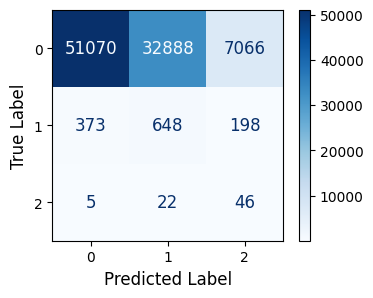

In [17]:
loaded_model.fit(X_train_mod, y_train)
# Predictions on the test set
y_pred = loaded_model.predict(X_test_mod)

# Accuracy Score
accuracy = accuracy_score(y_test, y_pred)
print(f"\nAccuracy Score: {accuracy:.4f}")

# Print the classification report
print("Classification Report:")
print(classification_report(y_test, y_pred))

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot confusion matrix with a custom colormap
cmap = sns.color_palette("Blues", as_cmap=True)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)

plt.figure(figsize=(4, 3))
ax = plt.gca()
disp.plot(cmap=cmap, ax=ax, values_format='d', text_kw={"fontsize": 12})
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.show()

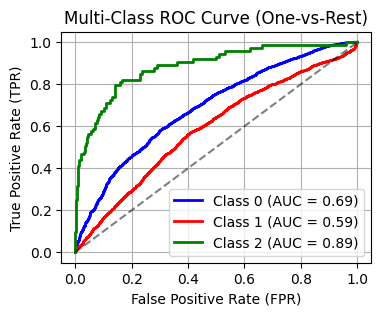

In [18]:
# Binarize the labels for multi-class classification
n_classes = len(np.unique(y_test))  # Number of classes
y_test_bin = label_binarize(y_test, classes=np.unique(y_test))  # Convert to one-hot encoding
y_pred_proba = loaded_model.predict_proba(X_test_mod)  # Get predicted probabilities for each class

# Plot ROC curve for each class
plt.figure(figsize=(4, 3))

colors = ['blue', 'red', 'green', 'brown']  # Adjust for more classes

for i in range(n_classes):
    fpr, tpr, thresholds = roc_curve(y_test_bin[:, i], y_pred_proba[:, i])  # Compute ROC for class i
    roc_auc = auc(fpr, tpr)  # Compute AUC
    plt.plot(fpr, tpr, color=colors[i % len(colors)], lw=2, label=f'Class {i} (AUC = {roc_auc:.2f})')

# Plot diagonal reference line
plt.plot([0, 1], [0, 1], linestyle='--', color='black', alpha=0.5)

# Labels and legend
plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")
plt.title("Multi-Class ROC Curve (One-vs-Rest)")
plt.legend()
plt.grid(True)
plt.show()

### Drop features and compare ###

In [19]:
# Drop these columns - BORUTA 
columns_to_drop=['MCHbconc','MPV','sex','basophil','nucRBC']

X_train_bor=X_train_mod.drop(columns=columns_to_drop)
X_test_bor=X_test_mod.drop(columns=columns_to_drop)
y_train_bor=training_mod['CH']
y_test_bor=test_mod['CH']


Accuracy Score: 0.5519
Classification Report:
              precision    recall  f1-score   support

         0.0       0.99      0.55      0.71     91024
         1.0       0.02      0.55      0.04      1219
         2.0       0.01      0.59      0.01        73

    accuracy                           0.55     92316
   macro avg       0.34      0.56      0.25     92316
weighted avg       0.98      0.55      0.70     92316



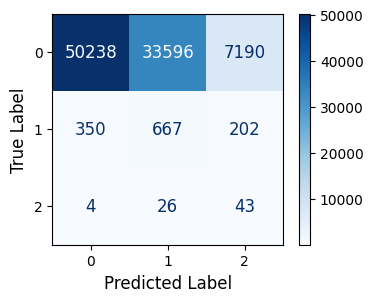

In [20]:
loaded_model.fit(X_train_bor, y_train_bor)
# Predictions on the test set
y_pred = loaded_model.predict(X_test_bor)

# Accuracy Score
accuracy = accuracy_score(y_test_bor, y_pred)
print(f"\nAccuracy Score: {accuracy:.4f}")

# Print the classification report
print("Classification Report:")
print(classification_report(y_test_bor, y_pred))

# Compute confusion matrix
cm = confusion_matrix(y_test_bor, y_pred)

# Plot confusion matrix with a custom colormap
cmap = sns.color_palette("Blues", as_cmap=True)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)

plt.figure(figsize=(4, 3))
ax = plt.gca()
disp.plot(cmap=cmap, ax=ax, values_format='d', text_kw={"fontsize": 12})
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.show()

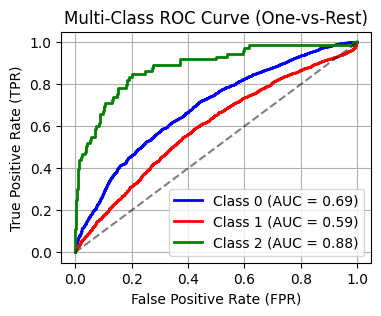

In [21]:
# Binarize the labels for multi-class classification
n_classes = len(np.unique(y_test_bor))  # Number of classes
y_test_bin = label_binarize(y_test_bor, classes=np.unique(y_test_bor))  # Convert to one-hot encoding
y_pred_proba = loaded_model.predict_proba(X_test_bor)  # Get predicted probabilities for each class

# Plot ROC curve for each class
plt.figure(figsize=(4, 3))

colors = ['blue', 'red', 'green', 'brown']  # Adjust for more classes

for i in range(n_classes):
    fpr, tpr, thresholds = roc_curve(y_test_bin[:, i], y_pred_proba[:, i])  # Compute ROC for class i
    roc_auc = auc(fpr, tpr)  # Compute AUC
    plt.plot(fpr, tpr, color=colors[i % len(colors)], lw=2, label=f'Class {i} (AUC = {roc_auc:.2f})')

# Plot diagonal reference line
plt.plot([0, 1], [0, 1], linestyle='--', color='black', alpha=0.5)

# Labels and legend
plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")
plt.title("Multi-Class ROC Curve (One-vs-Rest)")
plt.legend()
plt.grid(True)
plt.show()

In [22]:
## # Drop these columns - emperical 
columns_to_drop=['MCHbconc','MPV','sex','basophil','nucRBC','MspCV','immret','MRV','MCHb']

X_train_final=X_train_mod.drop(columns=columns_to_drop)
X_test_final=X_test_mod.drop(columns=columns_to_drop)
y_train_final=training_mod['CH']
y_test_final=test_mod['CH']


Accuracy Score: 0.5525
Classification Report:
              precision    recall  f1-score   support

         0.0       0.99      0.55      0.71     91024
         1.0       0.02      0.54      0.04      1219
         2.0       0.01      0.63      0.01        73

    accuracy                           0.55     92316
   macro avg       0.34      0.57      0.25     92316
weighted avg       0.98      0.55      0.70     92316



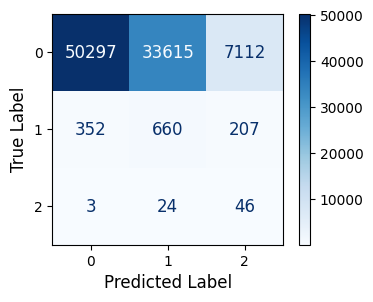

In [23]:
loaded_model.fit(X_train_final, y_train_final)
# Predictions on the test set
y_pred = loaded_model.predict(X_test_final)

# Accuracy Score
accuracy = accuracy_score(y_test_final, y_pred)
print(f"\nAccuracy Score: {accuracy:.4f}")

# Print the classification report
print("Classification Report:")
print(classification_report(y_test_final, y_pred))

# Compute confusion matrix
cm = confusion_matrix(y_test_final, y_pred)

# Plot confusion matrix with a custom colormap
cmap = sns.color_palette("Blues", as_cmap=True)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)

plt.figure(figsize=(4, 3))
ax = plt.gca()
disp.plot(cmap=cmap, ax=ax, values_format='d', text_kw={"fontsize": 12})
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.show()

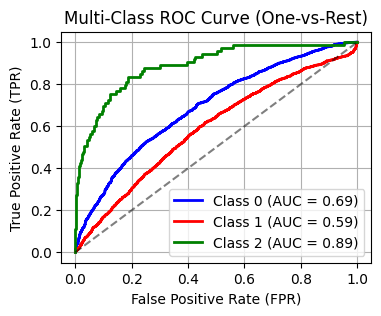

In [24]:
# Binarize the labels for multi-class classification
n_classes = len(np.unique(y_test_final))  # Number of classes
y_test_bin = label_binarize(y_test_final, classes=np.unique(y_test_final))  # Convert to one-hot encoding
y_pred_proba = loaded_model.predict_proba(X_test_final)  # Get predicted probabilities for each class

# Plot ROC curve for each class
plt.figure(figsize=(4, 3))

colors = ['blue', 'red', 'green', 'brown']  # Adjust for more classes

for i in range(n_classes):
    fpr, tpr, thresholds = roc_curve(y_test_bin[:, i], y_pred_proba[:, i])  # Compute ROC for class i
    roc_auc = auc(fpr, tpr)  # Compute AUC
    plt.plot(fpr, tpr, color=colors[i % len(colors)], lw=2, label=f'Class {i} (AUC = {roc_auc:.2f})')

# Plot diagonal reference line
plt.plot([0, 1], [0, 1], linestyle='--', color='black', alpha=0.5)

# Labels and legend
plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")
plt.title("Multi-Class ROC Curve (One-vs-Rest)")
plt.legend()
plt.grid(True)
plt.show()

### Optimize Threshold ###

In [25]:
classes = np.unique(y_train)
n_classes = len(classes)


# -----------------------------------------------------------
# Step 1: GENERATE OUT-OF-FOLD (OOF) PROBABILITIES
# -----------------------------------------------------------
print("\n--- Generating OOF Predictions for Threshold Tuning ---")

# Initialize the model with the extracted best parameters
best_model_for_oof = BalancedRandomForestClassifier(**best_params_RF)

# Initialize KFold for OOF generation
kf = KFold(n_splits=5, shuffle=True, random_state=seed)

# Initialize array to store OOF probabilities (shape: n_samples, n_classes)
oof_probs = np.zeros((X_train_mod.shape[0], n_classes))

# Iterate through CV folds to generate OOF predictions
for train_index, val_index in kf.split(X_train_mod):
    X_train_fold, X_val_fold = X_train_mod.iloc[train_index], X_train_mod.iloc[val_index]
    y_train_fold, y_val_fold = y_train.iloc[train_index], y_train.iloc[val_index]

    best_model_for_oof.fit(X_train_fold, y_train_fold)

    # Predict probabilities for ALL classes
    oof_probs[val_index, :] = best_model_for_oof.predict_proba(X_val_fold)

# -----------------------------------------------------------
# Step 2: DETERMINE OPTIMAL THRESHOLDS (One-vs-Rest for 3 Classes)
# -----------------------------------------------------------
print("\n--- Determining Optimal OvR Thresholds (Youden's J) ---")

y_train_bin = label_binarize(y_train, classes=classes)
optimal_thresholds = {}

# Iterate through each class to find its optimal OvR threshold
for i, class_label in enumerate(classes):
    # Compute ROC curve values for Class i vs. All Others
    fpr, tpr, thresholds = roc_curve(y_train_bin[:, i], oof_probs[:, i])

    # Calculate Youden's J statistic
    youden_j = tpr - fpr

    # Find the threshold that maximizes Youden's J
    optimal_threshold_index = np.argmax(youden_j)
    optimal_threshold_i = thresholds[optimal_threshold_index]

    optimal_thresholds[class_label] = optimal_threshold_i
    print(f"Optimal OvR Threshold for Class {class_label}: {optimal_threshold_i:.4f}")
    
'''
# -----------------------------------------------------------
# Step 2: DETERMINE OPTIMAL THRESHOLDS (One-vs-Rest for 3 Classes)
# -----------------------------------------------------------
print("\n--- Determining Optimal OvR Thresholds (Youden's J) ---")

y_train_bin = label_binarize(y_train_mod, classes=classes)
# Assuming optimal_thresholds dictionary and all input variables are defined
optimal_thresholds = {}

# Define the positive class label you want to maximize recall for
RECALL_OPTIMIZATION_CLASS = 2 

print("\n--- Determining Class-Specific Optimal Thresholds ---")

for i, class_label in enumerate(classes):
    # Compute ROC curve values for Class i vs. All Others
    fpr, tpr, thresholds = roc_curve(y_train_bin[:, i], oof_probs[:, i])

    if class_label == RECALL_OPTIMIZATION_CLASS:
        print(f"Applying Recall/F-score optimization for Class {class_label}...")
        
        # 1. Get Precision and Recall values (needed for F-score)
        precision, recall, pr_thresholds = precision_recall_curve(y_train_bin[:, i], oof_probs[:, i])
        
        # 2. Since precision_recall_curve returns 1 fewer threshold, pad the precision array
        # to match the length of the probability thresholds
        # Note: pr_thresholds are the probabilities *above* which a positive prediction is made.
        # The last recall and precision values correspond to a probability threshold of 1.0 (or max prob)

        # The thresholds array is usually shorter than precision/recall by 1. We match lengths:
        pr_thresholds_full = np.append(pr_thresholds, pr_thresholds[-1]) 
        
        # 3. Calculate F2-score (beta=2 weights Recall twice as much as Precision)
        # Handle division by zero for precision+recall=0 cases
        f2_scores = np.divide(
            (1 + 2**2) * precision * recall, 
            (2**2 * precision) + recall,
            out=np.zeros_like(precision), # Handle the 0/0 case by setting to 0
            where=((precision + recall) != 0)
        )

    else:
        print(f"Applying Youden's J optimization for Class {class_label}...")
        
        # Calculate Youden's J statistic (TPR - FPR)
        youden_j = tpr - fpr

        # Find the threshold that maximizes Youden's J
        optimal_threshold_index = np.argmax(youden_j)
        optimal_threshold_i = thresholds[optimal_threshold_index]

    optimal_thresholds[class_label] = optimal_threshold_i
    print(f"Optimal OvR Threshold for Class {class_label}: {optimal_threshold_i:.4f}")
    '''


--- Generating OOF Predictions for Threshold Tuning ---

--- Determining Optimal OvR Thresholds (Youden's J) ---
Optimal OvR Threshold for Class 0.0: 0.3741
Optimal OvR Threshold for Class 1.0: 0.3772
Optimal OvR Threshold for Class 2.0: 0.3090


'\n# -----------------------------------------------------------\n# Step 2: DETERMINE OPTIMAL THRESHOLDS (One-vs-Rest for 3 Classes)\n# -----------------------------------------------------------\nprint("\n--- Determining Optimal OvR Thresholds (Youden\'s J) ---")\n\ny_train_bin = label_binarize(y_train_mod, classes=classes)\n# Assuming optimal_thresholds dictionary and all input variables are defined\noptimal_thresholds = {}\n\n# Define the positive class label you want to maximize recall for\nRECALL_OPTIMIZATION_CLASS = 2 \n\nprint("\n--- Determining Class-Specific Optimal Thresholds ---")\n\nfor i, class_label in enumerate(classes):\n    # Compute ROC curve values for Class i vs. All Others\n    fpr, tpr, thresholds = roc_curve(y_train_bin[:, i], oof_probs[:, i])\n\n    if class_label == RECALL_OPTIMIZATION_CLASS:\n        print(f"Applying Recall/F-score optimization for Class {class_label}...")\n        \n        # 1. Get Precision and Recall values (needed for F-score)\n        pr

In [26]:
# -----------------------------------------------------------
# Step 3: REFIT FINAL MODEL ON ENTIRE TRAINING DATA
# -----------------------------------------------------------
print("\n--- Refitting Final Model on Entire Training Set ---")

# The final model is retrained on all data with the best hyperparameters
final_model_RF = BalancedRandomForestClassifier(**best_params_RF)
final_model_RF.fit(X_train_mod, y_train)



--- Refitting Final Model on Entire Training Set ---


BalancedRandomForestClassifier(bootstrap=True, max_depth=15,
                               max_features='log2', min_samples_leaf=12,
                               min_samples_split=18, n_estimators=233,
                               random_state=345, replacement=True,
                               sampling_strategy='all')


--- Final Evaluation on Test Set ---

Accuracy Score (Optimal OvR Thresholds): 0.5553

Classification Report (Optimal OvR Thresholds):
              precision    recall  f1-score   support

         0.0       0.99      0.56      0.71     91024
         1.0       0.02      0.51      0.04      1219
         2.0       0.01      0.67      0.01        73

    accuracy                           0.56     92316
   macro avg       0.34      0.58      0.25     92316
weighted avg       0.98      0.56      0.70     92316


--- Plotting ROC-AUC Curve ---


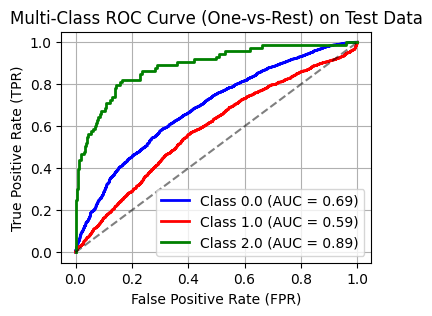

In [27]:
from collections import OrderedDict # Useful for guaranteeing class order
# -----------------------------------------------------------
# Step 5: EVALUATE ON TEST SET & GENERATE PLOTS
# -----------------------------------------------------------
print("\n--- Final Evaluation on Test Set ---")

# Get probability predictions on the test set (shape: n_samples, n_classes)
y_proba_test = final_model_RF.predict_proba(X_test_mod)

# --- Preparation before the loop ---

# 1. Ensure your optimal_thresholds dictionary is ordered by class index [0, 1, 2...]
# (Assuming your 'classes' array is [0, 1, 2] and optimal_thresholds contains those keys)
# Create an array of thresholds in the same order as y_proba's columns
# This is the CRITICAL FIX:
ordered_threshold_array = np.array([optimal_thresholds[c] for c in classes])

# Initialize the list for custom predictions
y_pred_custom = []

# Iterate over each sample's probability vector
for prob_vector in y_proba_test: # Renamed to y_proba_test for clarity
    
    # Identify classes where probability exceeds its threshold (using the ordered array)
    # The result is the index (column number) of the passing classes
    passing_classes_indices = np.where(prob_vector >= ordered_threshold_array)[0]
    
    if passing_classes_indices.size > 0:
        # If one or more classes pass, find the one with the highest probability *among them*
        # 1. Get the probabilities for the passing classes
        passing_probs = prob_vector[passing_classes_indices]
        # 2. Find the index within the 'passing_classes_indices' array that maximizes this probability
        max_passing_index_in_list = np.argmax(passing_probs)
        # 3. Use this index to get the actual column index
        chosen_class_index = passing_classes_indices[max_passing_index_in_list]
        
        # Map the column index back to the actual class label (0, 1, or 2)
        chosen_class = classes[chosen_class_index]
    else:
        # Otherwise, default to the class with the maximum probability
        chosen_class_index = np.argmax(prob_vector)
        chosen_class = classes[chosen_class_index]
        
    y_pred_custom.append(chosen_class)

y_pred_optimal_threshold = np.array(y_pred_custom) # Final result array

# --- 5a. Report Final Metrics (Using Optimal Thresholds) ---
accuracy = accuracy_score(y_test, y_pred_optimal_threshold)
print(f"\nAccuracy Score (Optimal OvR Thresholds): {accuracy:.4f}")
print("\nClassification Report (Optimal OvR Thresholds):")
print(classification_report(y_test, y_pred_optimal_threshold))


# --- 5b. Plot ROC-AUC Curve (Uses y_proba_test) ---
print("\n--- Plotting ROC-AUC Curve ---")
y_test_bin = label_binarize(y_test, classes=classes)
colors = ['blue', 'red', 'green', 'brown']

plt.figure(figsize=(4, 3))
for i in range(n_classes):
    fpr, tpr, thresholds = roc_curve(y_test_bin[:, i], y_proba_test[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=colors[i % len(colors)], lw=2, label=f'Class {classes[i]} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], linestyle='--', color='black', alpha=0.5)
plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")
plt.title("Multi-Class ROC Curve (One-vs-Rest) on Test Data")
plt.legend(loc="lower right")
plt.grid(True)


--- Plotting Confusion Matrix ---


Text(0, 0.5, 'True Label')

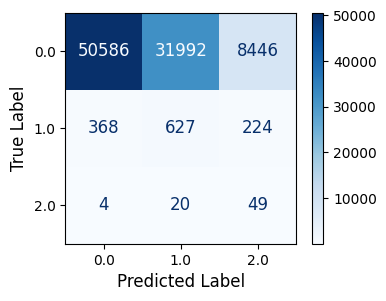

In [28]:
# --- 5c. Plot Confusion Matrix (Uses y_pred_optimal_threshold) ---
print("\n--- Plotting Confusion Matrix ---")
cmap = sns.color_palette("Blues", as_cmap=True)
cm = confusion_matrix(y_test, y_pred_optimal_threshold)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)

plt.figure(figsize=(4, 3))
ax = plt.gca()
disp.plot(cmap=cmap, ax=ax, values_format='d', text_kw={"fontsize": 12})
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)

### Plots of histogram ###

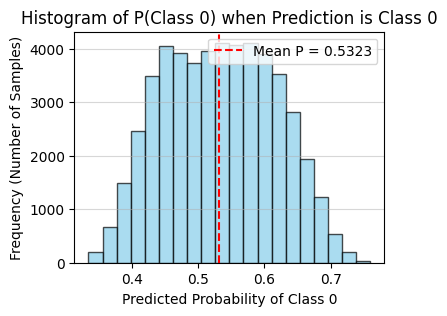

In [99]:
TARGET_CLASS = 0
PROB_CLASS =0

# Find the column index for the target class in y_proba_test
class_index = np.where(classes == PROB_CLASS)[0][0]

# Create a boolean mask where the final prediction is the target class
is_target_class = (y_pred_optimal_threshold == TARGET_CLASS)

# Select the relevant probabilities
filtered_probabilities = y_proba_test[is_target_class, class_index]

plt.figure(figsize=(4, 3))
plt.hist(filtered_probabilities, bins=20, edgecolor='black', color='skyblue', alpha=0.7)

plt.title(f'Histogram of P(Class {PROB_CLASS}) when Prediction is Class {TARGET_CLASS}')
plt.xlabel(f'Predicted Probability of Class {TARGET_CLASS}')
plt.ylabel('Frequency (Number of Samples)')
plt.grid(axis='y', alpha=0.5)

mean_prob = filtered_probabilities.mean()
plt.axvline(mean_prob, color='red', linestyle='dashed', linewidth=1.5, label=f'Mean P = {mean_prob:.4f}')
plt.legend()

plt.show()

### Save Model with thresholds ###

In [29]:
# 1. Create a package dictionary to store all deployment components
deployment_package = {
    'model': final_model_RF,
    'optimal_thresholds': optimal_thresholds,
    'classes': classes.tolist(), # Convert numpy array to list for clean saving
    'features': X_train_mod.columns.tolist() # (Optional) Good practice to save feature list
}

# 2. Save the trained model
with open("models/3class_BRF_baseline_giantplt_thresh.pkl", "wb") as f:
    pickle.dump(deployment_package,f)

print("Model saved successfully as 3class_BRF_baseline_giantplt_thresh.pkl")

Model saved successfully as 3class_BRF_baseline_giantplt_thresh.pkl


In [45]:
with open("models/3class_BRF_baseline_giantplt_thresh.pkl", "rb") as f:
    loaded_package = pickle.load(f)

loaded_model = loaded_package['model']
loaded_features = loaded_package['features']
loaded_thresholds = loaded_package['optimal_thresholds']
loaded_classes = loaded_package['classes']

print("Model Features:",loaded_features)
print("Model thresholds:",loaded_thresholds)

Model Features: ['sex', 'RBC', 'Hbconc', 'MCV', 'MCHb', 'MCHbconc', 'RDW', 'platelet', 'plateletcrit', 'MPV', 'lymphocyte', 'monocyte', 'neutrophil', 'eosinophil', 'basophil', 'nucRBC', 'reticulocyte', 'MRV', 'MspCV', 'immret', 'age', 'giant_plt']
Model thresholds: {0.0: 0.37409706108518054, 1.0: 0.37717024984049125, 2.0: 0.309028168483651}


## Model Versions ##

In [46]:
# Features used in ASH model
cols_to_keep=['RBC','Hbconc', 'MCV', 'RDW', 'platelet','plateletcrit','lymphocyte','monocyte', 'neutrophil', 
              'eosinophil', 'reticulocyte','age','giant_plt','CH']


# Features for all_of_us and bioVU
#cols_to_keep=['RBC','Hbconc', 'MCV', 'MCHb', 'RDW', 'platelet','lymphocyte','monocyte', 'neutrophil', 
              #'eosinophil', 'basophil','age','CH']

training_df_evaluate=training_mod[cols_to_keep]
test_df_evaluate=test_mod[cols_to_keep]

X_train_mod=training_df_evaluate.drop(columns=['CH'])
y_train_mod=training_df_evaluate[['CH']]
X_test_mod=test_df_evaluate.drop(columns=['CH'])
y_test_mod=test_df_evaluate[['CH']]

In [47]:
X_train_mod.columns.to_list

<bound method IndexOpsMixin.tolist of Index(['RBC', 'Hbconc', 'MCV', 'RDW', 'platelet', 'plateletcrit', 'lymphocyte',
       'monocyte', 'neutrophil', 'eosinophil', 'reticulocyte', 'age',
       'giant_plt'],
      dtype='object')>

### Load the baseline model ###

In [48]:
import pickle
seed = 345

# -----------------------------------------------------------
# Load the saved model and extract parameters
# -----------------------------------------------------------
print("--- Loading Model and Extracting Parameters ---")
with open("models/3class_BRF_baseline_giantplt_thresh.pkl", "rb") as f:
    loaded_package = pickle.load(f)

loaded_model = loaded_package['model']
best_params_RF = loaded_model.get_params()
loaded_features = loaded_package['features']
loaded_thresholds = loaded_package['optimal_thresholds']
loaded_classes = loaded_package['classes']

--- Loading Model and Extracting Parameters ---


### Get performance with default ###

/Users/riyanandi/Desktop/UKBB/myenv/lib/python3.9/site-packages/sklearn/base.py:1474: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)



Accuracy Score: 0.5525
Classification Report:
              precision    recall  f1-score   support

         0.0       0.99      0.55      0.71     91024
         1.0       0.02      0.54      0.04      1219
         2.0       0.01      0.63      0.01        73

    accuracy                           0.55     92316
   macro avg       0.34      0.57      0.25     92316
weighted avg       0.98      0.55      0.70     92316



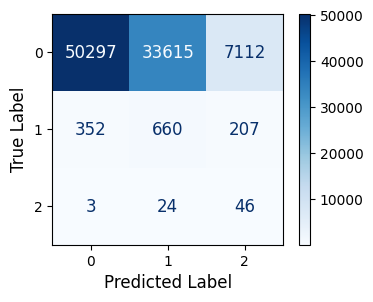

In [34]:
loaded_model.fit(X_train_mod, y_train_mod)
# Predictions on the test set
y_pred = loaded_model.predict(X_test_mod)

# Accuracy Score
accuracy = accuracy_score(y_test_mod, y_pred)
print(f"\nAccuracy Score: {accuracy:.4f}")

# Print the classification report
print("Classification Report:")
print(classification_report(y_test_mod, y_pred))

# Compute confusion matrix
cm = confusion_matrix(y_test_mod, y_pred)

# Plot confusion matrix with a custom colormap
cmap = sns.color_palette("Blues", as_cmap=True)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)

plt.figure(figsize=(4, 3))
ax = plt.gca()
disp.plot(cmap=cmap, ax=ax, values_format='d', text_kw={"fontsize": 12})
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.show()

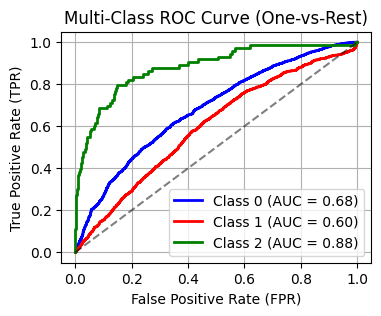

In [21]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# Binarize the labels for multi-class classification
n_classes = len(np.unique(y_test_mod))  # Number of classes
y_test_bin = label_binarize(y_test_mod, classes=np.unique(y_test_mod))  # Convert to one-hot encoding
y_pred_proba = loaded_model.predict_proba(X_test_mod)  # Get predicted probabilities for each class

# Plot ROC curve for each class
plt.figure(figsize=(4, 3))

colors = ['blue', 'red', 'green', 'brown']  # Adjust for more classes

for i in range(n_classes):
    fpr, tpr, thresholds = roc_curve(y_test_bin[:, i], y_pred_proba[:, i])  # Compute ROC for class i
    roc_auc = auc(fpr, tpr)  # Compute AUC
    plt.plot(fpr, tpr, color=colors[i % len(colors)], lw=2, label=f'Class {i} (AUC = {roc_auc:.2f})')

# Plot diagonal reference line
plt.plot([0, 1], [0, 1], linestyle='--', color='black', alpha=0.5)

# Labels and legend
plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")
plt.title("Multi-Class ROC Curve (One-vs-Rest)")
plt.legend()
plt.grid(True)
plt.show()

### Retrain model on ASH subset ###

In [49]:
# -----------------------------------------------------------
# Step 3: REFIT FINAL MODEL ON ENTIRE TRAINING DATA
# -----------------------------------------------------------
print("\n--- Refitting Final Model on Entire Training Set ---")
best_params_RF = loaded_model.get_params()
# The final model is retrained on all data with the best hyperparameters
final_model_RF = BalancedRandomForestClassifier(**best_params_RF)
final_model_RF.fit(X_train_mod, y_train_mod)


--- Refitting Final Model on Entire Training Set ---


/Users/riyanandi/Desktop/UKBB/myenv/lib/python3.9/site-packages/sklearn/base.py:1474: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


BalancedRandomForestClassifier(bootstrap=True, max_depth=15,
                               max_features='log2', min_samples_leaf=12,
                               min_samples_split=18, n_estimators=233,
                               random_state=345, replacement=True,
                               sampling_strategy='all')


--- Final Evaluation on Test Set ---
Number of fallback cases: 723

Accuracy Score (Optimal OvR Thresholds): 0.5460

Classification Report (Optimal OvR Thresholds):
              precision    recall  f1-score   support

         0.0       0.99      0.55      0.70     91024
         1.0       0.02      0.49      0.04      1219
         2.0       0.01      0.73      0.01        73

    accuracy                           0.55     92316
   macro avg       0.34      0.59      0.25     92316
weighted avg       0.98      0.55      0.70     92316


--- Plotting ROC-AUC Curve ---


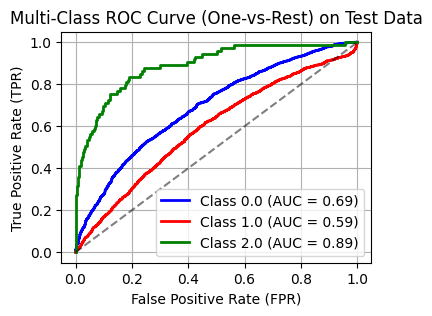

In [51]:
classes = np.unique(y_train_mod)
n_classes = len(classes)
optimal_thresholds=loaded_thresholds

from collections import OrderedDict # Useful for guaranteeing class order
# -----------------------------------------------------------
# Step 5: EVALUATE ON TEST SET & GENERATE PLOTS
# -----------------------------------------------------------
print("\n--- Final Evaluation on Test Set ---")

# Get probability predictions on the test set (shape: n_samples, n_classes)
y_proba_test = final_model_RF.predict_proba(X_test_mod)

ordered_threshold_array = np.array([optimal_thresholds[c] for c in classes])

# Initialize the list for custom predictions
y_pred_custom = []

# Iterate over each sample's probability vector
for prob_vector in y_proba_test: # Renamed to y_proba_test for clarity
    
    # Identify classes where probability exceeds its threshold (using the ordered array)
    # The result is the index (column number) of the passing classes
    passing_classes_indices = np.where(prob_vector >= ordered_threshold_array)[0]
    
    if passing_classes_indices.size > 0:
        # If one or more classes pass, find the one with the largest margin (prob - threshold)
        # 1. Compute margins for the passing classes
        passing_margins = prob_vector[passing_classes_indices] - ordered_threshold_array[passing_classes_indices]
        
        # 2. Find the index within the 'passing_classes_indices' array that maximizes this margin
        max_passing_index_in_list = np.argmax(passing_margins)
        
        # 3. Use this index to get the actual column index (i.e., class index)
        chosen_class_index = passing_classes_indices[max_passing_index_in_list]
        
        # Map the column index back to the actual class label (0, 1, or 2)
        chosen_class = classes[chosen_class_index]
    else:
        # Otherwise, default to the class with the maximum margin or maximum probability
        #margins = prob_vector - ordered_threshold_array
        #chosen_class_index = np.argmax(margins)
        chosen_class_index = np.argmax(prob_vector)
        chosen_class = classes[chosen_class_index]
        
    y_pred_custom.append(chosen_class)


y_pred_optimal_threshold = np.array(y_pred_custom)

num_fallbacks = sum(
    np.all(prob_vector < ordered_threshold_array) for prob_vector in y_proba_test
)
print("Number of fallback cases:", num_fallbacks)


# --- 5a. Report Final Metrics (Using Optimal Thresholds) ---
accuracy = accuracy_score(y_test_mod, y_pred_optimal_threshold)
print(f"\nAccuracy Score (Optimal OvR Thresholds): {accuracy:.4f}")
print("\nClassification Report (Optimal OvR Thresholds):")
print(classification_report(y_test_mod, y_pred_optimal_threshold))


# --- 5b. Plot ROC-AUC Curve (Uses y_proba_test) ---
print("\n--- Plotting ROC-AUC Curve ---")
y_test_bin = label_binarize(y_test_mod, classes=classes)
colors = ['blue', 'red', 'green', 'brown']

plt.figure(figsize=(4, 3))
for i in range(n_classes):
    fpr, tpr, thresholds = roc_curve(y_test_bin[:, i], y_proba_test[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=colors[i % len(colors)], lw=2, label=f'Class {classes[i]} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], linestyle='--', color='black', alpha=0.5)
plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")
plt.title("Multi-Class ROC Curve (One-vs-Rest) on Test Data")
plt.legend(loc="lower right")
plt.grid(True)


--- Plotting Confusion Matrix ---


Text(0, 0.5, 'True Label')

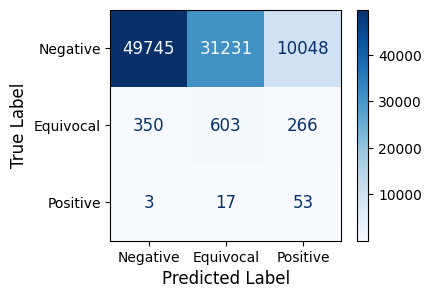

In [52]:
# --- 5c. Plot Confusion Matrix (Uses y_pred_optimal_threshold) ---
print("\n--- Plotting Confusion Matrix ---")
cmap = sns.color_palette("Blues", as_cmap=True)
cm = confusion_matrix(y_test_mod, y_pred_optimal_threshold)
class_names = ["Negative", "Equivocal", "Positive"]
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

plt.figure(figsize=(4, 3))
ax = plt.gca()
disp.plot(cmap=cmap, ax=ax, values_format='d', text_kw={"fontsize": 12})
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)

### Save model version ###

In [44]:
import pickle

# 1. Create a package dictionary to store all deployment components
deployment_package = {
    'model': final_model_RF,
    'optimal_thresholds': optimal_thresholds,
    'classes': classes.tolist(), # Convert numpy array to list for clean saving
    'features': X_train_mod.columns.tolist() # (Optional) Good practice to save feature list
}

# 2. Save the trained model
with open("models/3class_BRF_giantplt_ASH_latest.pkl", "wb") as f:
    pickle.dump(deployment_package,f)

print("Model saved successfully as 3class_BRF_giantplt_ASH_latest.pkl")

Model saved successfully as 3class_BRF_giantplt_ASH_latest.pkl


In [50]:
import pickle
with open("models/3class_BRF_giantplt_ASH_latest.pkl", "rb") as f:
    loaded_package = pickle.load(f)

loaded_model = loaded_package['model']
loaded_features = loaded_package['features']
loaded_thresholds = loaded_package['optimal_thresholds']
loaded_classes = loaded_package['classes']

print("Model Features:",loaded_features)
print("Model thresholds:",loaded_thresholds)

Model Features: ['RBC', 'Hbconc', 'MCV', 'RDW', 'platelet', 'plateletcrit', 'lymphocyte', 'monocyte', 'neutrophil', 'eosinophil', 'reticulocyte', 'age', 'giant_plt']
Model thresholds: {0.0: 0.37409706108518054, 1.0: 0.37717024984049125, 2.0: 0.309028168483651}


## CHECKS ##

In [8]:
import pickle
seed = 345

# -----------------------------------------------------------
# Load the saved model and extract parameters
# -----------------------------------------------------------
print("--- Loading Model and Extracting Parameters ---")
with open("models/3class_BRF_giantplt_ASH.pkl", "rb") as f:
    loaded_package = pickle.load(f)

loaded_model = loaded_package['model']
best_params_RF = loaded_model.get_params()

--- Loading Model and Extracting Parameters ---


In [10]:
features = loaded_package['features']
features

['RBC',
 'Hbconc',
 'MCV',
 'RDW',
 'platelet',
 'plateletcrit',
 'lymphocyte',
 'monocyte',
 'neutrophil',
 'eosinophil',
 'reticulocyte',
 'age',
 'giant_plt']

In [19]:
thresholds = loaded_package['optimal_thresholds']
thresholds

{0.0: 0.39538905302627386, 1.0: 0.36597126445037914, 2.0: 0.3028333765922183}

In [21]:
thresholds[0.0]

0.39538905302627386

In [9]:
test_pos=test_mod[test_mod['CH']==0]
test_pos.iloc[35]

sex               1.000000
RBC               4.557000
Hbconc           14.760000
MCV              92.850000
MCHb             32.400000
MCHbconc         34.890000
RDW              13.370000
platelet        309.000000
plateletcrit      0.272000
MPV               8.810000
lymphocyte        2.870000
monocyte          0.650000
neutrophil        6.400000
eosinophil        0.160000
basophil          0.040000
nucRBC            0.000000
reticulocyte      0.048000
MRV             107.980000
MspCV            75.570000
immret            0.400000
age              46.416667
giant_plt         0.000000
CH                0.000000
Name: 36, dtype: float64